# First Name: Jack
# Last Name: Kelly

# Import Libraries  

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.stats.multicomp as multi 
import matplotlib.pyplot as plt

# Import Data

In [56]:
bottledata = pd.read_csv('Bottle.csv', low_memory = False)
pd.set_option('display.float_format', lambda x:'%f'%x)

# Data management 

In [57]:
sub1 = bottledata.copy()

#grab data from last year of recording, 2021
sub1['Year'] = sub1['Depth_ID'].astype(str)
sub1['Year'] = sub1['Year'].apply(lambda x: x[:2] + x[3:])
sub1['Year'] = sub1['Year'].str[:4]
sub1['Year'] = pd.to_numeric(sub1['Year'], errors = 'coerce')
sub1 = sub1[sub1['Year'] == 2021]

#recode data for categorical var.
recode = { 3 : 'Observed Data', 4 : 'Educated Guess', 5 : 'Data from STD or CTD Sensor', 6 : 'Duplicate Depth', 7 : 'Interpolated to Standard Depth'}
sub1['BottleQuality'] = sub1['RecInd'].map(recode)

#make sure depth is around the 10m depth (plus minus 1m)
sub1 = sub1[(sub1['Depthm'] >= 9) & (sub1['Depthm'] <= 11)]

#grab only selected variables
sub1 = sub1[['BottleQuality', 'NH3uM']]

#drop missing readings (they dont give us info on misreadings)
sub1 = sub1.dropna(subset = ['NH3uM'])

print(len(sub1))
sub1.head()

160


,BottleQuality,NH3uM
892946,Observed Data,0.210000
892967,Interpolated to Standard Depth,0.240000
892968,Observed Data,0.250000
893016,Observed Data,1.220000
893024,Observed Data,0.270000


# Box Plot

Text(0, 0.5, 'Micromoles of Ammonia per L Seawater')

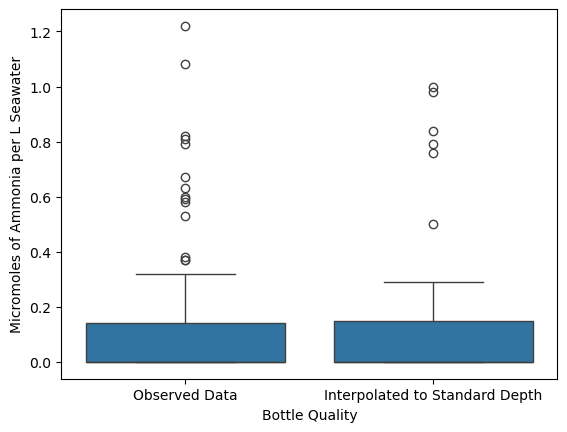

In [58]:
fig = plt.figure()
sns.boxplot(x = 'BottleQuality', y = 'NH3uM', data = sub1)
plt.xlabel('Bottle Quality')
plt.ylabel('Micromoles of Ammonia per L Seawater')

# ANOVA

In [59]:
model1 = smf.ols(formula = 'NH3uM ~ BottleQuality', data = sub1).fit()
print (model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  NH3uM   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.2493
Date:                Wed, 08 Apr 2026   Prob (F-statistic):              0.618
Time:                        16:13:15   Log-Likelihood:                -4.1754
No. Observations:                 160   AIC:                             12.35
Df Residuals:                     158   BIC:                             18.50
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [60]:
print('means')
m1 = sub1.groupby('BottleQuality').mean()
print (m1)

means
                                  NH3uM
BottleQuality                          
Interpolated to Standard Depth 0.145333
Observed Data                  0.123391


In [61]:
print('standard deviations')
sd1 = sub1.groupby('BottleQuality').std()
print (sd1)

standard deviations
                                  NH3uM
BottleQuality                          
Interpolated to Standard Depth 0.282228
Observed Data                  0.236294
